# Disk + bulge rotation curves fitted with the Courteau model

This notebook converts the physical mock cases into the exact Courteau
parameterization used by `glint.source.Vrot_Courteau1997`.

- Total baryonic mass: $10^{11}\,M_\odot$
- Exponential thin disk: $R_d=0.85$ kpc
- Hernquist bulge: $B/T=0.10, 0.25, 0.50$ and $R_{e,b}=0.3, 0.6$ kpc
- One NFW comparison: $B/T=0.20$, $R_{e,b}=0.6$ kpc, $M_{200}=3\times10^{11}M_\odot$, $c_{200}=4$

The physical grid remains in `mock_kinematics_physical_params.py`. The fitted
Courteau parameters are exported to JSON/CSV for the later mock-recovery
notebook.

## Imports and paths

In [1]:
import csv
import importlib
import json
import sys
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.cosmology import FlatLambdaCDM
from astropy.table import Table
from scipy.optimize import least_squares

%matplotlib inline

cwd = Path.cwd().resolve()
if (cwd / "examples" / "mock_kinematics_physical_params.py").exists():
    EXAMPLE_DIR = cwd / "examples"
elif (cwd / "mock_kinematics_physical_params.py").exists():
    EXAMPLE_DIR = cwd
else:
    raise FileNotFoundError("Run this notebook from the glint repository or examples directory.")

REPO_ROOT = EXAMPLE_DIR.parent
for path in (REPO_ROOT, EXAMPLE_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from glint.mass_model import disk_plus_bulge_vcirc_components, nfw_halo_vcirc2
from glint.source import Vrot_Courteau1997
import mock_kinematics_physical_params as config
importlib.reload(config)

JSON_OUTPUT = EXAMPLE_DIR / "mock_kinematics_courteau_fits.json"
CSV_OUTPUT = EXAMPLE_DIR / "mock_kinematics_courteau_fits.csv"
FIGURE_DIR = EXAMPLE_DIR / "figure"
FIGURE_STEM = FIGURE_DIR / "courteau_disk_bulge_grid_with_dm_comparison"

print("example directory:", EXAMPLE_DIR)
print("physical cases:", len(config.physical_cases()))

example directory: /lwk/atsujita/HATLASJ0900/glint/examples
physical cases: 7


## Physical experiment grid

The total mass is held fixed while mass is redistributed between disk and
bulge. The table below is the single source of truth used by this notebook and
the future mock-cube generator.

In [2]:
physical_case_table = Table(
    rows=[
        (
            case["name"],
            case["bulge_to_total"],
            case["bulge_effective_radius_kpc"],
            case["disk_mass_msun"],
            case["bulge_mass_msun"],
            case["has_dark_matter"],
            case["halo_mass_200_msun"],
        )
        for case in config.physical_cases()
    ],
    names=("case", "B/T", "Re_bulge [kpc]", "M_disk [Msun]", "M_bulge [Msun]", "DM", "M200 [Msun]"),
)
physical_case_table

case,B/T,Re_bulge [kpc],M_disk [Msun],M_bulge [Msun],DM,M200 [Msun]
str12,float64,float64,float64,float64,bool,float64
bt10_re03,0.1,0.3,90000000000.0,10000000000.0,False,0.0
bt10_re06,0.1,0.6,90000000000.0,10000000000.0,False,0.0
bt25_re03,0.25,0.3,75000000000.0,25000000000.0,False,0.0
bt25_re06,0.25,0.6,75000000000.0,25000000000.0,False,0.0
bt50_re03,0.5,0.3,50000000000.0,50000000000.0,False,0.0
bt50_re06,0.5,0.6,50000000000.0,50000000000.0,False,0.0
bt20_re06_dm,0.2,0.6,80000000000.0,20000000000.0,True,300000000000.0


## Baryonic circular-velocity model

The shared implementation lives in `glint.mass`, rather than in this
notebook. The disk is a razor-thin exponential disk and the bulge is a
Hernquist sphere with $a=R_e/1.8153$. Component velocities are combined in
quadrature, $V_c^2=V_d^2+V_b^2$.

In [3]:
def evaluate_physical_curve(case: dict, radius_kpc: np.ndarray) -> tuple[np.ndarray, ...]:
    """Return disk, bulge, halo, and quadrature-summed total speeds."""
    disk_velocity, bulge_velocity, baryon_velocity = disk_plus_bulge_vcirc_components(
        radius_kpc,
        disk_mass_msun=case["disk_mass_msun"],
        disk_scale_radius_kpc=case["disk_scale_radius_kpc"],
        bulge_mass_msun=case["bulge_mass_msun"],
        bulge_effective_radius_kpc=case["bulge_effective_radius_kpc"],
    )
    if case["has_dark_matter"]:
        halo_velocity = np.sqrt(nfw_halo_vcirc2(
            radius_kpc,
            mass_200_msun=case["halo_mass_200_msun"],
            radius_200_kpc=case["halo_radius_200_kpc"],
            concentration_200=case["halo_concentration_200"],
        ))
    else:
        halo_velocity = np.zeros_like(radius_kpc)
    total_velocity = np.sqrt(baryon_velocity**2 + halo_velocity**2)
    return disk_velocity, bulge_velocity, halo_velocity, total_velocity

## Courteau fit

The fit uses the same function as the production forward model. It is first
performed with broad bounds to test the flexibility of the function itself.
The result is then checked against the narrower bounds currently used in
`params_kinematics.py`; those narrower bounds are not imposed during this
conversion.

In [4]:
def ordered_values(mapping: dict[str, float]) -> np.ndarray:
    return np.array(
        [mapping["v_c_kms"], mapping["r_turn_arcsec"], mapping["beta"], mapping["gamma"]],
        dtype=float,
    )


def courteau_curve(radius_arcsec: np.ndarray, theta: np.ndarray) -> np.ndarray:
    v_c_kms, r_turn_arcsec, beta, gamma = theta
    return Vrot_Courteau1997(
        r=radius_arcsec,
        v_c=v_c_kms,
        r_turn=r_turn_arcsec,
        beta=beta,
        gamma=gamma,
    )


def fit_courteau(radius_arcsec: np.ndarray, physical_velocity_kms: np.ndarray):
    """Fit the exact Courteau implementation used by glint."""
    initial = ordered_values(config.COURTEAU_INITIAL)
    lower = np.array([config.COURTEAU_FIT_BOUNDS[key][0] for key in config.COURTEAU_INITIAL])
    upper = np.array([config.COURTEAU_FIT_BOUNDS[key][1] for key in config.COURTEAU_INITIAL])

    # Equal velocity weight per radial sample.  The fit convention is stored in
    # the JSON output so later experiments can reproduce or replace it.
    result = least_squares(
        lambda theta: courteau_curve(radius_arcsec, theta) - physical_velocity_kms,
        x0=initial,
        bounds=(lower, upper),
        x_scale="jac",
        ftol=1.0e-12,
        xtol=1.0e-12,
        gtol=1.0e-12,
        max_nfev=20_000,
    )
    if not result.success:
        raise RuntimeError(f"Courteau fit failed: {result.message}")
    return result


def inference_prior_diagnostics(parameters: dict[str, float]) -> tuple[bool, list[str]]:
    violations = []
    for key, bounds in config.CURRENT_INFERENCE_BOUNDS.items():
        value = parameters[key]
        if not bounds[0] <= value <= bounds[1]:
            violations.append(f"{key}={value:.6g} outside [{bounds[0]}, {bounds[1]}]")
    return not violations, violations

## Fit all nine cases

In [5]:
def fit_all_cases() -> tuple[dict, list[dict]]:
    cosmology = FlatLambdaCDM(H0=config.H0_KM_S_MPC, Om0=config.OMEGA_M)
    kpc_per_arcsec = (
        cosmology.angular_diameter_distance(config.SOURCE_REDSHIFT).to_value(u.kpc)
        * np.deg2rad(1.0 / 3600.0)
    )
    radius_arcsec = np.linspace(
        config.FIT_RADIUS_MIN_ARCSEC,
        config.FIT_RADIUS_MAX_ARCSEC,
        config.FIT_RADIUS_SAMPLES,
    )
    radius_kpc = radius_arcsec * kpc_per_arcsec

    critical_density = cosmology.critical_density(config.SOURCE_REDSHIFT).to_value(u.Msun / u.kpc**3)
    fitted_cases = []
    for input_case in config.physical_cases():
        case = dict(input_case)
        if case["has_dark_matter"]:
            case["halo_radius_200_kpc"] = (
                3.0 * case["halo_mass_200_msun"] / (4.0 * np.pi * 200.0 * critical_density)
            ) ** (1.0 / 3.0)
        else:
            case["halo_radius_200_kpc"] = 0.0
        disk_velocity, bulge_velocity, halo_velocity, total_velocity = evaluate_physical_curve(case, radius_kpc)
        result = fit_courteau(radius_arcsec, total_velocity)
        fitted_velocity = courteau_curve(radius_arcsec, result.x)
        residual = fitted_velocity - total_velocity

        names = tuple(config.COURTEAU_INITIAL)
        parameters = {name: float(value) for name, value in zip(names, result.x, strict=True)}
        prior_compatible, prior_violations = inference_prior_diagnostics(parameters)
        peak_index = int(np.argmax(total_velocity))
        peak_velocity = float(total_velocity[peak_index])
        outer_velocity = float(total_velocity[-1])

        fitted_cases.append(
            {
                **case,
                "courteau": parameters,
                "fit_quality": {
                    "rmse_kms": float(np.sqrt(np.mean(residual**2))),
                    "max_abs_residual_kms": float(np.max(np.abs(residual))),
                    "fractional_rmse": float(np.sqrt(np.mean(residual**2)) / peak_velocity),
                    "peak_radius_arcsec": float(radius_arcsec[peak_index]),
                    "peak_radius_kpc": float(radius_kpc[peak_index]),
                    "peak_velocity_kms": peak_velocity,
                    "outer_velocity_kms": outer_velocity,
                    "outer_to_peak_ratio": outer_velocity / peak_velocity,
                    "outer_drop_kms": peak_velocity - outer_velocity,
                    "optimizer_cost": float(result.cost),
                    "optimizer_nfev": int(result.nfev),
                },
                "current_inference_prior_compatible": prior_compatible,
                "current_inference_prior_violations": prior_violations,
                "plot_data": {
                    "radius_arcsec": radius_arcsec,
                    "radius_kpc": radius_kpc,
                    "disk_velocity_kms": disk_velocity,
                    "bulge_velocity_kms": bulge_velocity,
                    "halo_velocity_kms": halo_velocity,
                    "total_velocity_kms": total_velocity,
                    "courteau_velocity_kms": fitted_velocity,
                    "residual_kms": residual,
                },
            }
        )

    metadata = {
        "description": "Disk-plus-bulge curves and one modest-NFW comparison fitted by the glint Courteau model.",
        "source_redshift": config.SOURCE_REDSHIFT,
        "cosmology": {"H0_km_s_Mpc": config.H0_KM_S_MPC, "Omega_m": config.OMEGA_M},
        "kpc_per_arcsec": float(kpc_per_arcsec),
        "fit_radius_arcsec": [config.FIT_RADIUS_MIN_ARCSEC, config.FIT_RADIUS_MAX_ARCSEC],
        "fit_radius_samples": config.FIT_RADIUS_SAMPLES,
        "fit_weighting": "equal weight in velocity for uniformly spaced radius samples",
        "dark_matter_included": True,
        "courteau_formula": "V=vc*(1+r/rturn)^beta*(1+(r/rturn)^gamma)^(-1/gamma)*(r/rturn)^(1-beta)",
        "courteau_fit_bounds": config.COURTEAU_FIT_BOUNDS,
        "current_inference_bounds": config.CURRENT_INFERENCE_BOUNDS,
    }
    return metadata, fitted_cases

In [6]:
metadata, fitted_cases = fit_all_cases()
print(f"1 arcsec = {metadata['kpc_per_arcsec']:.3f} kpc")
print("fit radius [arcsec]:", metadata["fit_radius_arcsec"])
print("dark matter included:", metadata["dark_matter_included"])

1 arcsec = 5.699 kpc
fit radius [arcsec]: [0.02, 0.8]
dark matter included: True


## Fitted parameters and diagnostics

`Vout/Vpeak` quantifies how strongly the no-DM physical curve declines by the
outer fit radius. `prior OK` tells us whether the fitted Courteau parameters
are inside the current image-modeling priors.

In [7]:
summary_rows = []
for case in fitted_cases:
    params = case["courteau"]
    quality = case["fit_quality"]
    summary_rows.append(
        (
            case["name"],
            case["bulge_to_total"],
            case["bulge_effective_radius_kpc"],
            params["v_c_kms"],
            params["r_turn_arcsec"],
            params["beta"],
            params["gamma"],
            quality["rmse_kms"],
            quality["max_abs_residual_kms"],
            quality["outer_to_peak_ratio"],
            case["current_inference_prior_compatible"],
            "; ".join(case["current_inference_prior_violations"]),
        )
    )

summary_table = Table(
    rows=summary_rows,
    names=(
        "case", "B/T", "Re [kpc]", "vc [km/s]", "rturn [arcsec]", "beta", "gamma",
        "RMS [km/s]", "max |resid| [km/s]", "Vout/Vpeak", "prior OK", "prior violations",
    ),
)
for name in ("vc [km/s]", "rturn [arcsec]", "beta", "gamma", "RMS [km/s]", "max |resid| [km/s]", "Vout/Vpeak"):
    summary_table[name].format = ".3f"
summary_table

case,B/T,Re [kpc],vc [km/s],rturn [arcsec],beta,gamma,RMS [km/s],max |resid| [km/s],Vout/Vpeak,prior OK,prior violations
str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,bool,str32
bt10_re03,0.1,0.3,262.328,0.275,0.999,4.467,7.629,20.510,0.747,True,
bt10_re06,0.1,0.6,275.181,0.261,0.892,5.029,10.075,37.203,0.751,False,"gamma=5.02889 outside [1.0, 4.5]"
bt25_re03,0.25,0.3,309.216,0.151,0.999,2.337,19.627,59.087,0.724,True,
bt25_re06,0.25,0.6,267.655,0.239,0.999,3.717,9.645,24.755,0.739,True,
bt50_re03,0.5,0.3,347.881,0.062,0.999,3.625,29.819,108.410,0.546,True,
bt50_re06,0.5,0.6,298.377,0.133,0.999,2.783,16.587,35.661,0.694,True,
bt20_re06_dm,0.2,0.6,296.733,0.268,0.943,3.282,5.408,29.341,0.818,True,


## All physical curves and Courteau approximations

Black is the physical disk+bulge total, dotted curves are the individual
components, and red dashed is the Courteau fit. Every residual panel uses the
same velocity scale so the compact high-B/T mismatch remains visible.

In [8]:
def make_figure(metadata: dict, fitted_cases: list[dict]) -> plt.Figure:
    figure = plt.figure(figsize=(13.0, 16.5))
    # Reserve the upper 10 percent explicitly for the title and shared legend.
    # This is more predictable than constrained_layout for a nested 3x3 grid.
    outer_grid = figure.add_gridspec(
        3,
        3,
        left=0.075,
        right=0.985,
        bottom=0.055,
        top=0.885,
        hspace=0.20,
        wspace=0.13,
    )

    largest_residual = max(
        float(np.max(np.abs(case["plot_data"]["residual_kms"])))
        for case in fitted_cases
    )
    residual_limit = 10.0 * np.ceil(largest_residual / 10.0)

    main_axes = []
    residual_axes = []
    for index, case in enumerate(fitted_cases):
        row, column = divmod(index, 3)
        inner = outer_grid[row, column].subgridspec(2, 1, height_ratios=(3.4, 1.0), hspace=0.04)
        ax = figure.add_subplot(inner[0])
        residual_ax = figure.add_subplot(inner[1], sharex=ax)
        main_axes.append(ax)
        residual_axes.append(residual_ax)

        plot_data = case["plot_data"]
        total_label = "disk + bulge + halo" if case["has_dark_matter"] else "disk + bulge"
        ax.plot(plot_data["radius_kpc"], plot_data["total_velocity_kms"], color="black", lw=2.2, label=total_label)
        ax.plot(plot_data["radius_kpc"], plot_data["disk_velocity_kms"], color="tab:blue", lw=1.2, ls=":", label="disk")
        ax.plot(plot_data["radius_kpc"], plot_data["bulge_velocity_kms"], color="tab:green", lw=1.2, ls=":", label="bulge")
        if case["has_dark_matter"]:
            ax.plot(plot_data["radius_kpc"], plot_data["halo_velocity_kms"], color="tab:purple", lw=1.4, ls=":", label="NFW halo")
        ax.plot(plot_data["radius_kpc"], plot_data["courteau_velocity_kms"], color="tab:red", lw=1.8, ls="--", label="Courteau fit")

        quality = case["fit_quality"]
        params = case["courteau"]
        ax.set_title(
            f"B/T={case['bulge_to_total']:.2f},  $R_{{e,b}}$={case['bulge_effective_radius_kpc']:.1f} kpc"
            + ("  + NFW" if case["has_dark_matter"] else ""),
            fontsize=11,
        )
        ax.text(
            0.97,
            0.96,
            (
                f"$v_c$={params['v_c_kms']:.0f} km s$^{{-1}}$\n"
                f"$r_t$={params['r_turn_arcsec']:.3f} arcsec\n"
                f"$\\beta$={params['beta']:.2f}, $\\gamma$={params['gamma']:.2f}\n"
                f"RMS={quality['rmse_kms']:.1f} km s$^{{-1}}$\n"
                f"$V_{{out}}/V_{{peak}}$={quality['outer_to_peak_ratio']:.2f}"
            ),
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8.5,
            bbox={"facecolor": "white", "edgecolor": "0.75", "alpha": 0.88, "boxstyle": "round,pad=0.3"},
        )
        residual_ax.axhline(0.0, color="0.35", lw=0.8)
        residual_ax.plot(plot_data["radius_kpc"], plot_data["residual_kms"], color="tab:red", lw=1.2)
        # Use one common scale so the visibly larger model mismatch in compact,
        # high-B/T cases is not hidden by per-panel autoscaling.
        residual_ax.set_ylim(-residual_limit, residual_limit)
        residual_ax.grid(alpha=0.2)
        ax.grid(alpha=0.2)
        plt.setp(ax.get_xticklabels(), visible=False)

        if column == 0:
            ax.set_ylabel("Circular velocity [km s$^{-1}$]")
            residual_ax.set_ylabel("fit - true\n[km s$^{-1}$]", fontsize=8)
        if index >= len(fitted_cases) - 3:
            residual_ax.set_xlabel("Radius [kpc]")

    velocity_max = max(float(np.max(case["plot_data"]["total_velocity_kms"])) for case in fitted_cases)
    for ax in main_axes:
        ax.set_xlim(0.0, config.FIT_RADIUS_MAX_ARCSEC * metadata["kpc_per_arcsec"])
        ax.set_ylim(0.0, 1.10 * velocity_max)
    handles, labels = main_axes[0].get_legend_handles_labels()
    figure.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.925),
        ncol=4,
        frameon=False,
    )
    figure.suptitle(
        (
            "Baryonic rotation curves, one NFW comparison, and Courteau approximations\n"
            f"$M_{{disk}}+M_{{bulge}}=10^{{11}}$ M$_\\odot$, "
            f"$R_{{d}}={config.DISK_SCALE_RADIUS_KPC:.2f}$ kpc, z={config.SOURCE_REDSHIFT:.3f}"
        ),
        fontsize=15,
        y=0.985,
    )
    return figure

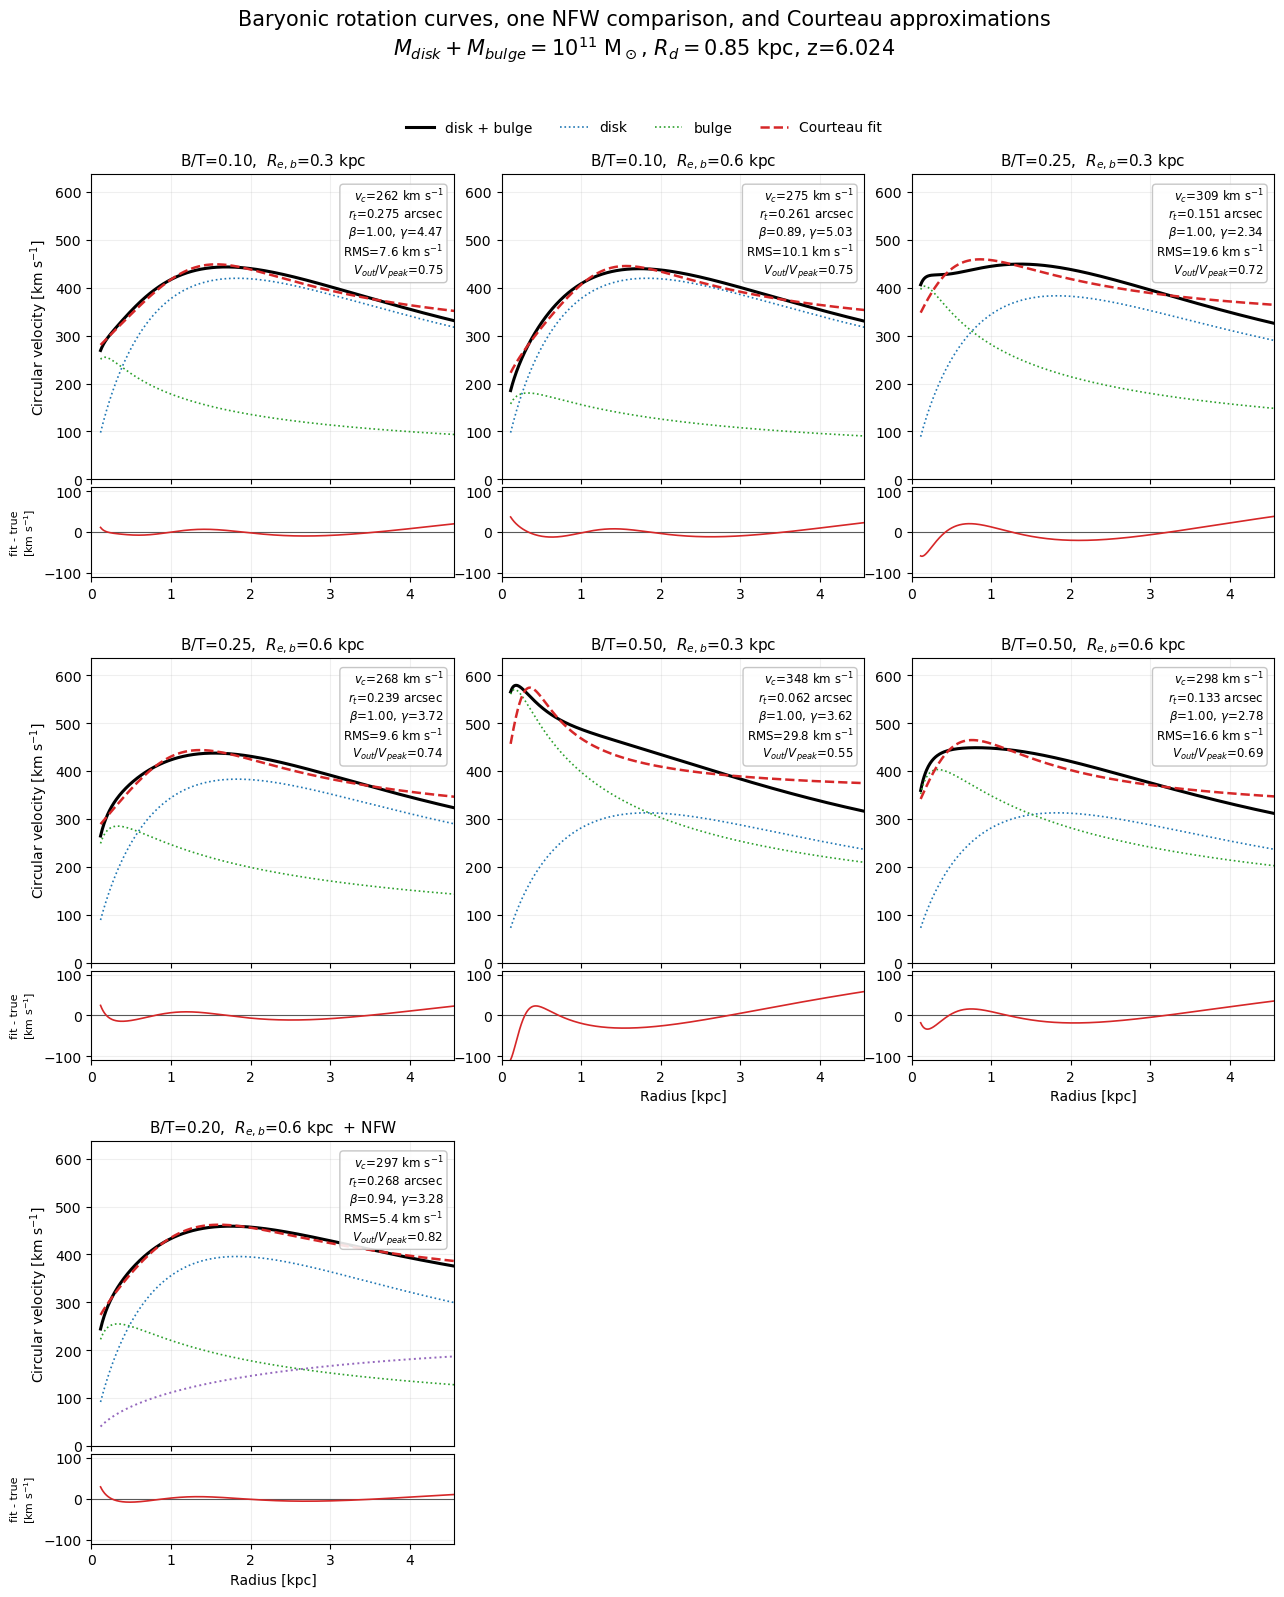

saved: /lwk/atsujita/HATLASJ0900/glint/examples/figure/courteau_disk_bulge_grid_with_dm_comparison.png
saved: /lwk/atsujita/HATLASJ0900/glint/examples/figure/courteau_disk_bulge_grid_with_dm_comparison.pdf


In [9]:
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
figure = make_figure(metadata, fitted_cases)
figure.savefig(FIGURE_STEM.with_suffix(".png"), dpi=220, bbox_inches="tight")
figure.savefig(FIGURE_STEM.with_suffix(".pdf"), bbox_inches="tight")
plt.show()
print("saved:", FIGURE_STEM.with_suffix(".png"))
print("saved:", FIGURE_STEM.with_suffix(".pdf"))

## Export parameters for mock-cube generation

In [10]:
def serializable_case(case: dict) -> dict:
    """Drop dense plotting arrays from the persistent parameter file."""
    return {key: value for key, value in case.items() if key != "plot_data"}


def write_outputs(metadata: dict, fitted_cases: list[dict]) -> None:
    payload = {"metadata": metadata, "cases": [serializable_case(case) for case in fitted_cases]}
    JSON_OUTPUT.write_text(json.dumps(payload, indent=2) + "\n", encoding="utf-8")

    fieldnames = [
        "name",
        "bulge_to_total",
        "bulge_effective_radius_kpc",
        "disk_mass_msun",
        "bulge_mass_msun",
        "has_dark_matter",
        "halo_mass_200_msun",
        "halo_radius_200_kpc",
        "halo_concentration_200",
        "v_c_kms",
        "r_turn_arcsec",
        "beta",
        "gamma",
        "rmse_kms",
        "max_abs_residual_kms",
        "outer_to_peak_ratio",
        "outer_drop_kms",
        "current_inference_prior_compatible",
        "current_inference_prior_violations",
    ]
    with CSV_OUTPUT.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        for case in fitted_cases:
            writer.writerow(
                {
                    "name": case["name"],
                    "bulge_to_total": case["bulge_to_total"],
                    "bulge_effective_radius_kpc": case["bulge_effective_radius_kpc"],
                    "disk_mass_msun": case["disk_mass_msun"],
                    "bulge_mass_msun": case["bulge_mass_msun"],
                    "has_dark_matter": case["has_dark_matter"],
                    "halo_mass_200_msun": case["halo_mass_200_msun"],
                    "halo_radius_200_kpc": case["halo_radius_200_kpc"],
                    "halo_concentration_200": case["halo_concentration_200"],
                    **case["courteau"],
                    "rmse_kms": case["fit_quality"]["rmse_kms"],
                    "max_abs_residual_kms": case["fit_quality"]["max_abs_residual_kms"],
                    "outer_to_peak_ratio": case["fit_quality"]["outer_to_peak_ratio"],
                    "outer_drop_kms": case["fit_quality"]["outer_drop_kms"],
                    "current_inference_prior_compatible": case["current_inference_prior_compatible"],
                    "current_inference_prior_violations": "; ".join(case["current_inference_prior_violations"]),
                }
            )

In [11]:
write_outputs(metadata, fitted_cases)
print("saved:", JSON_OUTPUT)
print("saved:", CSV_OUTPUT)

saved: /lwk/atsujita/HATLASJ0900/glint/examples/mock_kinematics_courteau_fits.json
saved: /lwk/atsujita/HATLASJ0900/glint/examples/mock_kinematics_courteau_fits.csv


## How to interpret the result

- Large `RMS` or structured residuals indicate that Courteau cannot reproduce
  the physical baryonic curve exactly.
- A fitted parameter on a broad-fit boundary indicates a limitation of the
  Courteau shape rather than an inference failure.
- `prior OK = False` means the recovery notebook priors must be widened before
  using that case.
- A low `Vout/Vpeak` quantifies the outer decline that a dark-matter component
  may need to flatten.

This notebook only performs the physical-to-Courteau conversion. Beam
convolution, noise injection, and parameter recovery belong in the separate
image-modeling notebook.